# Исследовательская часть

* Анализ данных
* Обучение модели
* Сохранение

## Loading the Dataset

In [1]:
import pandas as pd
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter

import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

c:\Users\79017\Documents\Education\heart_disease\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_path = "heart.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "johnsmith88/heart-disease-dataset",
    file_path,
)

C:\Users\79017\AppData\Local\Temp\ipykernel_10088\1748445174.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [3]:
print(df.describe())

               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.000000     0.000000    71.000000  

Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


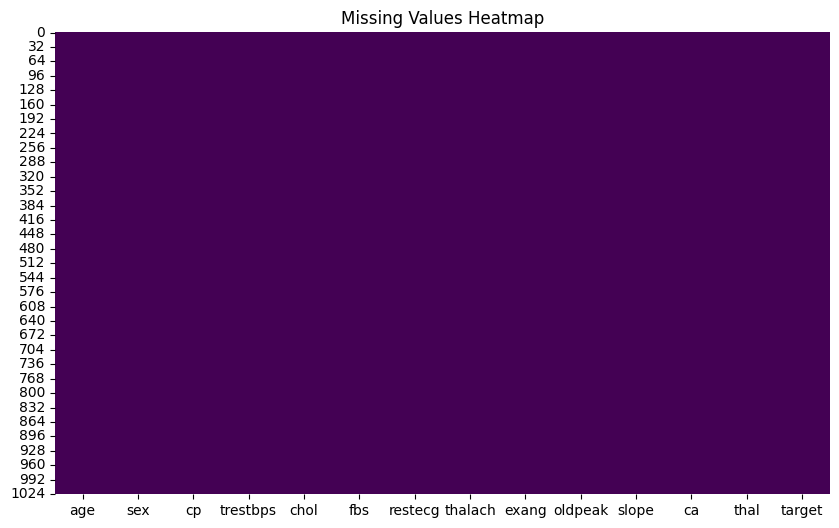

In [14]:
missing_vals = df.isnull().sum()
missing_pct = (missing_vals / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_vals, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing Values'] > 0])

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [15]:
df.duplicated().sum()

np.int64(723)

## Обучение модели

In [ ]:
X = df.drop(columns=["target"])  # Признаки
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = CatBoostClassifier(
    iterations=100,
    random_seed=42,
)

In [22]:
model.fit(X_train, y_train)

Learning rate set to 0.078187
0:	learn: 0.6613033	total: 1.48ms	remaining: 146ms
1:	learn: 0.6311135	total: 2.47ms	remaining: 121ms
2:	learn: 0.6031462	total: 3.32ms	remaining: 107ms
3:	learn: 0.5788238	total: 4.17ms	remaining: 100ms
4:	learn: 0.5563909	total: 5ms	remaining: 95.1ms
5:	learn: 0.5335361	total: 5.82ms	remaining: 91.1ms
6:	learn: 0.5172842	total: 6.68ms	remaining: 88.7ms
7:	learn: 0.5006243	total: 7.53ms	remaining: 86.6ms
8:	learn: 0.4857731	total: 8.53ms	remaining: 86.3ms
9:	learn: 0.4712553	total: 9.49ms	remaining: 85.4ms
10:	learn: 0.4565980	total: 10.4ms	remaining: 83.8ms
11:	learn: 0.4439337	total: 11.2ms	remaining: 82.5ms
12:	learn: 0.4321982	total: 12.1ms	remaining: 81.1ms
13:	learn: 0.4217458	total: 12.9ms	remaining: 79.6ms
14:	learn: 0.4102925	total: 13.8ms	remaining: 78.4ms
15:	learn: 0.3993949	total: 14.8ms	remaining: 77.5ms
16:	learn: 0.3906998	total: 15.7ms	remaining: 76.8ms
17:	learn: 0.3811349	total: 16.7ms	remaining: 76ms
18:	learn: 0.3717437	total: 17.6ms	

In [23]:
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.8975609756097561

In [26]:
model_save_path = "../models/catboost_model.cbm"
model.save_model(model_save_path)

### Test inference

In [30]:
model_load_path = "../models/catboost_model.cbm"
loaded_model = CatBoostClassifier().load_model(model_load_path)

In [33]:
_case = X_test.iloc[1].to_dict()

In [39]:
loaded_model.predict(pd.Series(_case))

np.int64(1)

In [40]:
_case

{'age': 53.0,
 'sex': 0.0,
 'cp': 2.0,
 'trestbps': 128.0,
 'chol': 216.0,
 'fbs': 0.0,
 'restecg': 0.0,
 'thalach': 115.0,
 'exang': 0.0,
 'oldpeak': 0.0,
 'slope': 2.0,
 'ca': 0.0,
 'thal': 0.0}